# **Task-03**

Build a decision tree classifier to predict whether a
customer will purchase a product or service based on their
demographic and behavioral data. Use a dataset such as
the Bank Marketing dataset from the UCI Machine Learning
Repository.

**1) Task objective**

Build a Decision Tree Classifier to predict whether a customer will purchase a product/service, using demographic and behavioral variables such as age, job, marital status, balance, housing loan, contact type, campaign history, and others. On the UCI page, the target is explicitly defined as whether the client subscribed a term deposit.

**Step 1: Import libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


**Interpretation:**

These libraries allow us to move through the complete machine learning workflow: loading data, understanding it, cleaning it, building a model, and checking performance.

**Step 2: Load dataset**

In [ ]:
df = pd.read_csv("bank-full.csv", sep=';')

**Interpretation:**

The UCI Bank Marketing dataset is commonly provided as a semicolon-separated CSV. The dataset includes customer attributes, campaign information, and the output variable y, which shows whether the client subscribed a term deposit.

**Step 3: Display first rows**

In [ ]:
print("First 5 rows:")
df.head()

First 5 rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
print("\nShape:")
print(df.shape)


Shape:
(45211, 17)


In [ ]:
print("\nColumns:")
print(df.columns.tolist())


Columns:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [ ]:
print("\nInfo:")
print(df.info())



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None


In [ ]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [ ]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 0


**Interpretation:**

->This step helps us understand:

-how many records are present

-what variables are available

-whether the dataset has null values or repeated rows

UCI indicates this dataset has no missing values for the older version and defines features like age, job, marital, education, balance, housing, loan, contact, month, duration, campaign, pdays, previous, poutcome, with target y.

**Step 4: Basic target distribution**

In [ ]:
print("\nTarget distribution:")
print(df['y'].value_counts())

print("\nTarget percentage:")
print(df['y'].value_counts(normalize=True) * 100)


Target distribution:
y
no     39922
yes     5289
Name: count, dtype: int64

Target percentage:
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


**Interpretation:**

This tells us whether the dataset is balanced or imbalanced.
In this dataset, the target is usually imbalanced, meaning many more customers did not subscribe than those who did. That matters because a high accuracy alone may be misleading if the model mostly predicts the majority class.

**Step 5: Exploratory analysis**

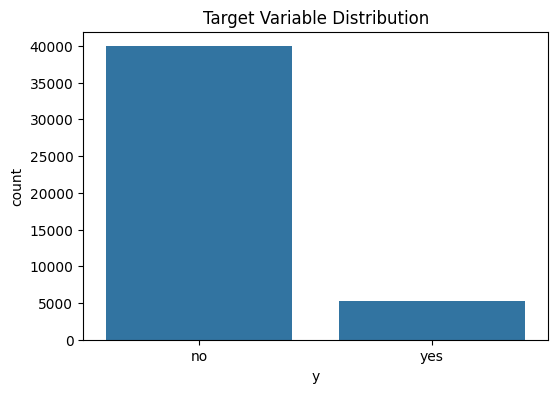

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='y', data=df)
plt.title("Target Variable Distribution")
plt.show()

**Interpretation:**

This shows the number of customers who subscribed and who did not.
If the no bar is much higher, it means positive responses are relatively rare.

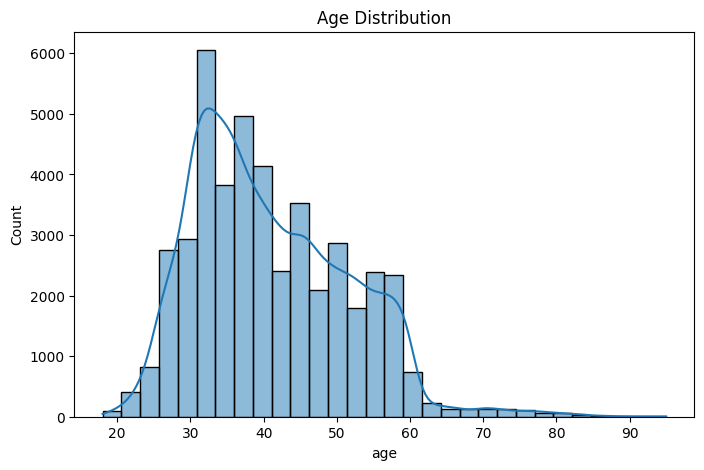

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

**Interpretation:**

This helps us see the age spread of customers.
It shows whether the customers are mostly middle-aged, younger, or older.
Age may influence customer response behavior.

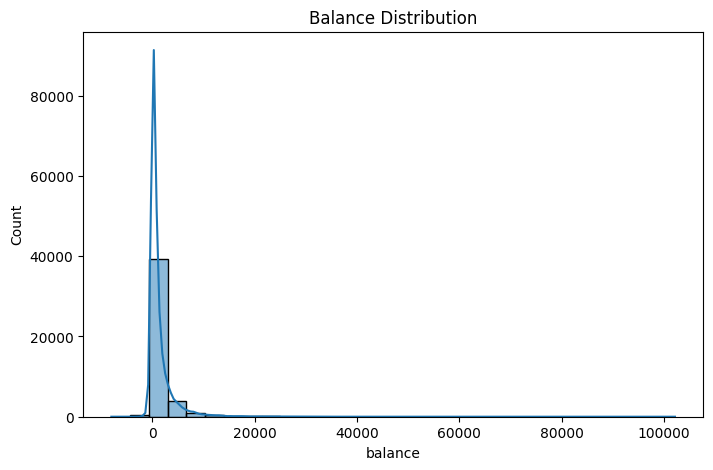

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['balance'], bins=30, kde=True)
plt.title("Balance Distribution")
plt.show()

**Interpretation:**

This shows the distribution of average yearly account balance.
Usually, balance is skewed, with many customers having moderate values and fewer customers having very high balances.

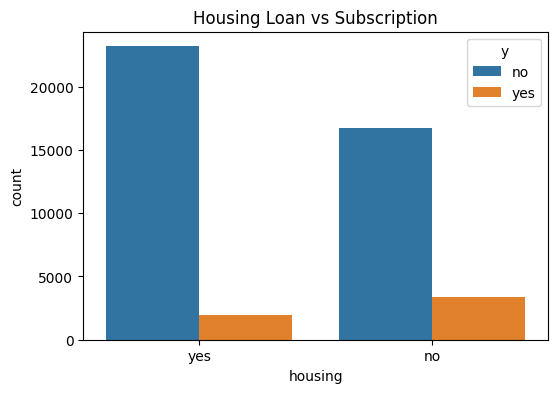

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='housing', hue='y', data=df)
plt.title("Housing Loan vs Subscription")
plt.show()

Interpretation

This lets us compare whether clients with housing loans were more or less likely to subscribe.
If the proportion of yes is lower among housing = yes, it may suggest housing loans reduce willingness to invest.

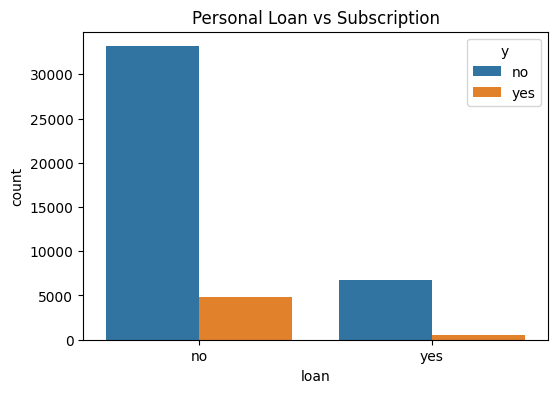

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='loan', hue='y', data=df)
plt.title("Personal Loan vs Subscription")
plt.show()

**Interpretation:**

This checks whether customers with personal loans are less likely to subscribe.
Loan burden can influence financial decision-making.

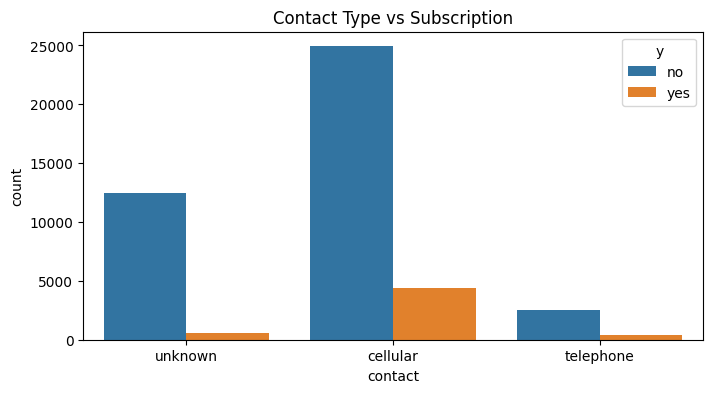

In [ ]:

plt.figure(figsize=(8,4))
sns.countplot(x='contact', hue='y', data=df)
plt.title("Contact Type vs Subscription")
plt.show()

**Interpretation:**

This compares response behavior across communication types such as cellular, telephone, or unknown.
If one contact mode has more successful outcomes, it may be more effective for marketing campaigns.

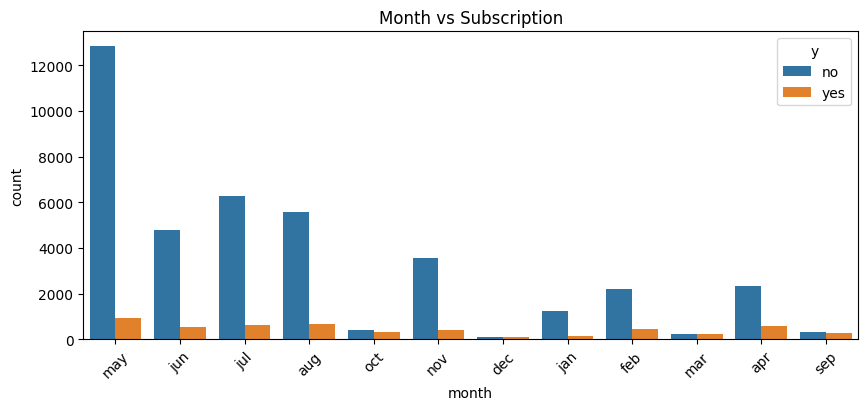

In [ ]:
plt.figure(figsize=(10,4))
sns.countplot(x='month', hue='y', data=df)
plt.title("Month vs Subscription")
plt.xticks(rotation=45)
plt.show()

**Interpretation:**

This helps identify whether campaign success changes by month.
Some months may perform better than others due to timing, seasonality, or campaign strategy.

**Step 6: Encode categorical variables**

In [ ]:
df_encoded = df.copy()

label_encoders = {}
for col in df_encoded.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

**Interpretation:**

Machine learning models like decision trees need numeric input.
Since many dataset columns are categorical, we encode them into numeric values before training.

**Step 7: Split features and target**

In [ ]:
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

**Interpretation:**

->X contains all predictor variables

->y contains the output to predict

This separates input data from the target class.

**Step 8: Train-test split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (36168, 16)
Testing set shape: (9043, 16)


**Interpretation**

We train the model on 80% of the data and test it on 20%.
Using stratify=y keeps the class proportions similar in both sets, which is especially important when the dataset is imbalanced.

**Step 9: Train Decision Tree Classifier**

In [ ]:
model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

**Interpretation**

A decision tree splits the data into branches using the most informative features.
Here:

->criterion='entropy' tells the model to use information gain

->max_depth=5 limits the tree size to reduce overfitting

->random_state=42 ensures reproducibility

A shallow tree is usually easier to interpret and better for internship demonstration.

**Step 10: Prediction**

In [ ]:
y_pred = model.predict(X_test)

**Interpretation**

Now the trained model predicts whether each customer in the test set will subscribe or not.

**Step 11: Evaluation**

In [ ]:
acc = accuracy_score(y_test, y_pred)
print("\nAccuracy:", acc)


Accuracy: 0.8893066460245493


**Interpretation:**

Accuracy gives the proportion of correct predictions.
But since this dataset is often imbalanced, accuracy should not be the only metric considered.

In [ ]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[7770  215]
 [ 786  272]]


**Interpretation:**

The confusion matrix shows:

1)true negatives

2)false positives

3)false negatives

4)true positives

This helps us see whether the model is missing too many actual subscribers or incorrectly predicting too many subscriptions.

In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7985
           1       0.56      0.26      0.35      1058

    accuracy                           0.89      9043
   macro avg       0.73      0.62      0.65      9043
weighted avg       0.87      0.89      0.87      9043



**Interpretation**

This gives:

->precision: how many predicted positives were correct

->recall: how many actual positives were found

->f1-score: balance between precision and recall

For marketing tasks, recall for the yes class can be important because missing potential subscribers may reduce campaign effectiveness.

**Step 12: Feature importance**


Feature Importances:
      Feature  Importance
11   duration    0.620705
8     contact    0.156910
13      pdays    0.081642
6     housing    0.072142
10      month    0.064993
9         day    0.001249
0         age    0.001223
5     balance    0.001135
7        loan    0.000000
4     default    0.000000
2     marital    0.000000
3   education    0.000000
1         job    0.000000
12   campaign    0.000000
14   previous    0.000000
15   poutcome    0.000000


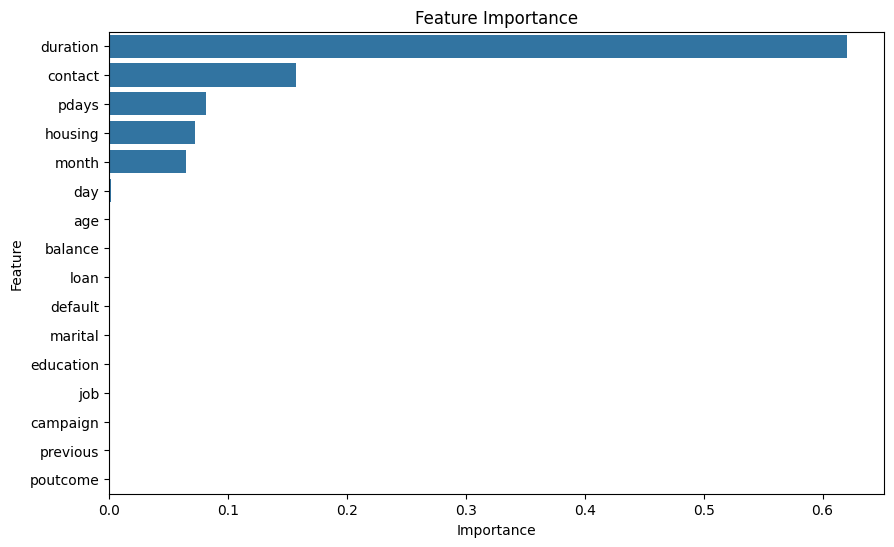

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)



print("\nFeature Importances:")
print(importance)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title("Feature Importance")
plt.show()


**Interpretation:**

This shows which variables influenced the decision tree most.
In this dataset, features such as duration, poutcome, pdays, campaign, contact, and month often become important because they are closely linked to campaign outcomes. The dataset documentation specifically defines these campaign-related variables and the prior-contact variables.

Note: duration often becomes very predictive, but in practice it may not always be suitable for pre-call prediction because it is known after or during the call, not before the campaign decision.

**Step 13: Visualize the Decision Tree**

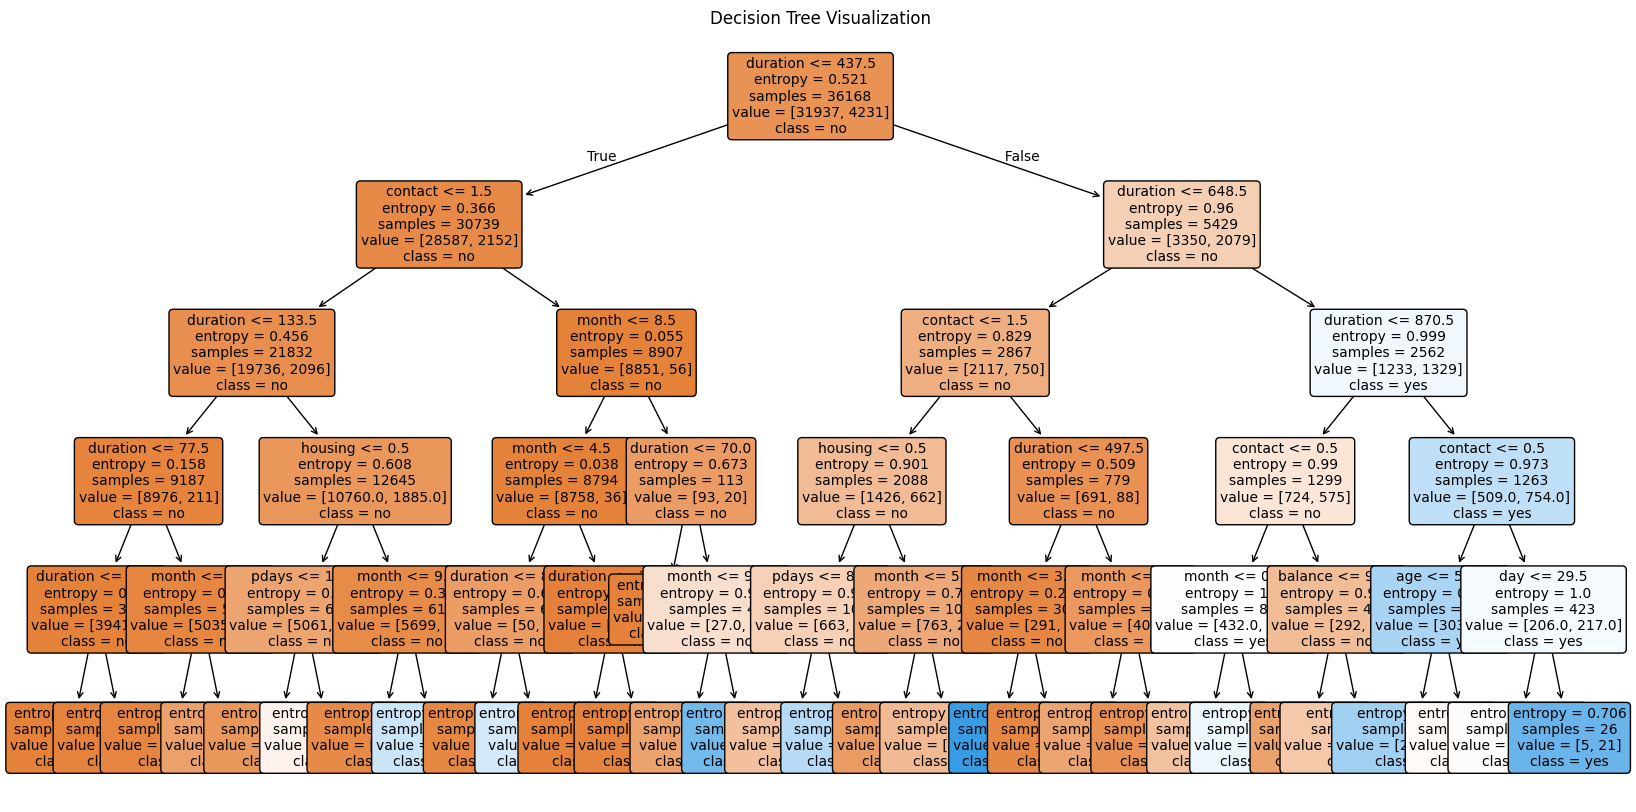

In [ ]:
plt.figure(figsize=(20,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['no', 'yes'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Visualization")
plt.show()

**Interpretation:**

**The tree diagram shows the sequence of rules the model uses, such as:**

->whether call duration is high or low

->whether previous campaign outcome was successful

->whether contact type is cellular

->whether campaign contacts were many or few

This makes the model easy to explain in a project presentation.


# **Conclusion:**

In this task, a Decision Tree Classifier was built using the UCI Bank Marketing dataset to predict whether a customer would subscribe to a term deposit. The dataset contains customer demographic and campaign-related attributes, and the target variable is y, which represents subscription outcome.

**The workflow included:**


*  loading and inspecting the dataset
*   checking class balance


*   performing exploratory data analysis
*   encoding categorical variables

*   splitting the data into training and testing sets
*   training a decision tree model

*   evaluating performance using accuracy, confusion matrix, and classification report
*   interpreting feature importance and visualizing the tree

The decision tree model is useful because it is both predictive and easy to interpret. The analysis typically shows that campaign-related features play a strong role in determining whether a customer subscribes.







